In [1]:
import datetime
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def int_row(row):
    x = [int(el) for el in row]
    if len(x) == 1:
        return x[0]
    return x

def float_row(row):
    x = [float(el) for el in row]
    if len(x) == 1:
        return x[0]
    return x

def string_row(row):
    if len(row) == 1:
        return row[0]
    return row

def read_results(csv_file:str, echo=print):
    with open(csv_file, 'r') as fp:
        reader = csv.reader(fp)
        # Check for the info block
        info = []
        skiprows = 0
        for line in reader:
            if len(line) > 1:
                if line[0].strip() == 'Date/Time':
                    break
                else:
                    info.append(line)
                    skiprows += 1
            else:
                skiprows += 1
    header_info = {}
    for line in info:
        try:
            # Need to adjust this for the DX coil system
            header_info[line[0]] = int_row(line[1:])
        except ValueError:
            try:
                header_info[line[0]] = float_row(line[1:])
            except ValueError:
                header_info[line[0]] = string_row(line[1:])
    df = pd.read_csv(csv_file, skiprows=skiprows)
    df['Date/Time'] = pd.to_datetime(df['Date/Time'], format='mixed')
    if 'maximum_date' in header_info:
        header_info['maximum_date'] = pd.to_datetime(header_info['maximum_date']).date()
    return header_info, df


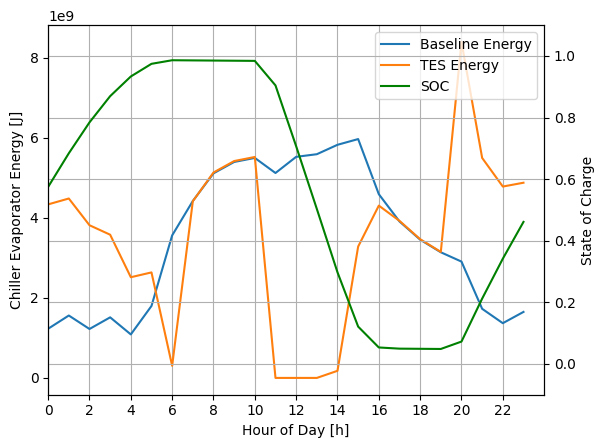

In [2]:
info, df = read_results('output-no-change.csv')
date = datetime.date(year=2006, month=7, day=7)
label = 'Chiller Evaporator'
df['date'] = df['Date/Time'].dt.date

soc_col = 'soc:PythonPlugin:OutputVariable [](Hourly)'
energy_cols = [el for el in df.columns.values.tolist() if 'Chiller Evaporator Cooling Energy' in el]
#print(energy_cols)
baseline_cols = []
tes_cols = []
for el in energy_cols:
    if 'Baseline' in el:
        baseline_cols.append(el)
    else:
        tes_cols.append(el)
assert(len(baseline_cols) == len(tes_cols))
dfx = df[df['date'] == date]
baseline = dfx[baseline_cols].sum(axis=1)
tes = dfx[tes_cols].sum(axis=1)
soc = dfx[soc_col]
label = 'Chiller Evaporator'
x = list(range(24))
#x = list(range(25))[1:]
fig, ax0 = plt.subplots()
ax0.plot(x, baseline, label='Baseline Energy')
ax0.plot(x, tes, label='TES Energy')
ax0.set_ylabel(f'{label} Energy [J]')
ax1 = ax0.twinx()
ax1.plot(x, soc, 'g', label='SOC')
ax1.set_ylabel('State of Charge')
ax1.set_yticks(np.arange(0, 1.1, 0.2))
ax1.set_ylim(-0.1,1.1)

ax0.set_xlabel('Hour of Day [h]')
ax0.set_xlim(0,24)
ax0.set_xticks(np.arange(0, 24, 2))
#ax0.legend(['one', 'two', 'three'],loc='center left')
lines0, labels0 = ax0.get_legend_handles_labels()
lines1, labels1 = ax1.get_legend_handles_labels()
ax0.legend(lines0 + lines1, labels0 + labels1, loc='upper right') #lower left')
ax0.grid(axis='x')
ax1.grid()
plt.show()

ymin, ymax = ax0.get_ylim()


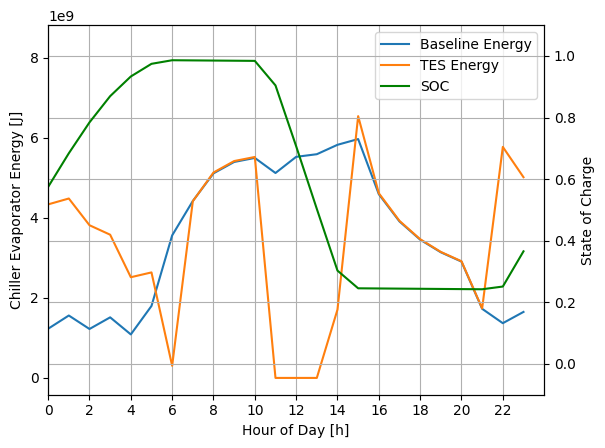

In [3]:
info, df = read_results('output-30pct-limit-with-recharge.csv')
date = datetime.date(year=2006, month=7, day=7)
label = 'Chiller Evaporator'
df['date'] = df['Date/Time'].dt.date

soc_col = 'soc:PythonPlugin:OutputVariable [](Hourly)'
energy_cols = [el for el in df.columns.values.tolist() if 'Chiller Evaporator Cooling Energy' in el]
#print(energy_cols)
baseline_cols = []
tes_cols = []
for el in energy_cols:
    if 'Baseline' in el:
        baseline_cols.append(el)
    else:
        tes_cols.append(el)
assert(len(baseline_cols) == len(tes_cols))
dfx = df[df['date'] == date]
baseline = dfx[baseline_cols].sum(axis=1)
tes = dfx[tes_cols].sum(axis=1)
soc = dfx[soc_col]
label = 'Chiller Evaporator'
x = list(range(24))
fig, ax0 = plt.subplots()
ax0.plot(x, baseline, label='Baseline Energy')
ax0.plot(x, tes, label='TES Energy')
ax0.set_ylabel(f'{label} Energy [J]')
ax0.set_ylim(ymin, ymax)
ax1 = ax0.twinx()
ax1.plot(x, soc, 'g', label='SOC')
ax1.set_ylabel('State of Charge')
ax1.set_yticks(np.arange(0, 1.1, 0.2))
ax1.set_ylim(-0.1,1.1)

ax0.set_xlabel('Hour of Day [h]')
ax0.set_xlim(0,24)
ax0.set_xticks(np.arange(0, 24, 2))
#ax0.legend(['one', 'two', 'three'],loc='center left')
lines0, labels0 = ax0.get_legend_handles_labels()
lines1, labels1 = ax1.get_legend_handles_labels()
ax0.legend(lines0 + lines1, labels0 + labels1, loc='upper right')
ax0.grid(axis='x')
ax1.grid()
plt.show()

In [ ]:
info, df = read_results('output-12-to-6.csv')
date = datetime.date(year=2006, month=7, day=7)
label = 'Chiller Evaporator'
df['date'] = df['Date/Time'].dt.date

soc_col = 'soc:PythonPlugin:OutputVariable [](Hourly)'
energy_cols = [el for el in df.columns.values.tolist() if 'Chiller Evaporator Cooling Energy' in el]
#print(energy_cols)
baseline_cols = []
tes_cols = []
for el in energy_cols:
    if 'Baseline' in el:
        baseline_cols.append(el)
    else:
        tes_cols.append(el)
assert(len(baseline_cols) == len(tes_cols))
dfx = df[df['date'] == date]
baseline = dfx[baseline_cols].sum(axis=1)
tes = dfx[tes_cols].sum(axis=1)
soc = dfx[soc_col]
label = 'Chiller Evaporator'
x = list(range(24))
fig, ax0 = plt.subplots()
ax0.plot(x, baseline, label='Baseline Energy')
ax0.plot(x, tes, label='TES Energy')
ax0.set_ylabel(f'{label} Energy [J]')
ax0.set_ylim(ymin, ymax)
ax1 = ax0.twinx()
ax1.plot(x, soc, 'g', label='SOC')
ax1.set_ylabel('State of Charge')
ax1.set_yticks(np.arange(0, 1.1, 0.2))
ax1.set_ylim(-0.1,1.1)

ax0.set_xlabel('Hour of Day [h]')
ax0.set_xlim(0,24)
ax0.set_xticks(np.arange(0, 24, 2))
#ax0.legend(['one', 'two', 'three'],loc='center left')
lines0, labels0 = ax0.get_legend_handles_labels()
lines1, labels1 = ax1.get_legend_handles_labels()
ax0.legend(lines0 + lines1, labels0 + labels1, loc='upper right')
ax0.grid(axis='x')
ax1.grid()
plt.show()